# Day 5 · Notebook 3 — Teach a robot by trial and error 🤖
### ML Bootcamp · Day 5 of 5

**Reinforcement learning (RL)**: nobody gives the robot the right answers. It **tries actions**, gets **rewards** or **penalties**, and slowly learns what works — like training a dog with treats.

In this notebook you will:
1. Build a **warehouse robot** world from scratch and teach it with **Q-learning** *(Part 1)*
2. Watch what it learned: its **Q-table** and its route *(Part 2)*
3. Train a **self-driving taxi** with the Gymnasium library *(Part 3)*

> No GPU needed. ✍️ = exercise (solutions at the end).

In [1]:
!pip install -q gymnasium

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output
plt.rcParams["font.size"] = 12
print("Ready!")

Ready!


---
## Part 1 · A warehouse robot
A 5×5 warehouse floor. The robot starts at the top-left **S** and must deliver a parcel to **G** (bottom-right). **█** = shelves (can't drive through).

**Rewards:** reach the goal **+100** · every move **−1** (saves battery) · bump into a shelf or wall **−5**.
**Actions:** 0 = up, 1 = down, 2 = left, 3 = right.

In [3]:
grid = np.array([[0, 0, 0, 0, 0],
                 [0, 1, 1, 0, 0],
                 [0, 0, 0, 1, 0],
                 [1, 1, 0, 1, 0],
                 [0, 0, 0, 0, 2]])      # 0 = floor, 1 = shelf, 2 = goal
N = 5
moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]
arrows = ["↑", "↓", "←", "→"]

def step(state, action):
    """The environment: given where the robot is and what it does, return (new_state, reward, done)."""
    r, c = divmod(state, N)
    dr, dc = moves[action]
    nr, nc = r + dr, c + dc
    if not (0 <= nr < N and 0 <= nc < N) or grid[nr, nc] == 1:
        return state, -5, False            # bump! stay where you are
    new_state = nr * N + nc
    if grid[nr, nc] == 2:
        return new_state, 100, True        # delivered!
    return new_state, -1, False

def show(state=None, path=()):
    for r in range(N):
        row = ""
        for c in range(N):
            s = r * N + c
            if s == state: row += " R "
            elif grid[r, c] == 1: row += " █ "
            elif grid[r, c] == 2: row += " G "
            elif s == 0: row += " S "
            elif s in path: row += " · "
            else: row += " . "
        print(row)

show(state=0)

 R  .  .  .  . 
 .  █  █  .  . 
 .  .  .  █  . 
 █  █  .  █  . 
 .  .  .  .  G 


### A robot that acts randomly
Before learning, the robot just wanders.

In [4]:
rng = np.random.default_rng(1)
state, total, steps = 0, 0, 0
for steps in range(1, 101):
    state, reward, done = step(state, rng.integers(4))
    total += reward
    if done: break
print(f"Random robot: {steps} moves, total reward {total}, delivered: {done}")

Random robot: 36 moves, total reward 9, delivered: True


### Q-learning
The robot keeps a **Q-table**: for every square (25) and every action (4), a score for "how good is this move here?". It starts at zero.

After every move it updates one score:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\big[\,r + \gamma \max_{a'} Q(s',a') - Q(s,a)\big]$$

In words: *new score = old score + a little bit × (reward now + best score from where I landed − old score)*.
- **α = 0.1** learning rate (how fast to update)
- **γ = 0.95** discount (future rewards count a bit less than rewards now)
- **ε (epsilon)**: chance to try a **random** move (explore) instead of the best-known move (exploit). Starts at 100%, drops to 5%.

Average reward, first 50 episodes: -83.46
Average reward, last 50 episodes:  91.8


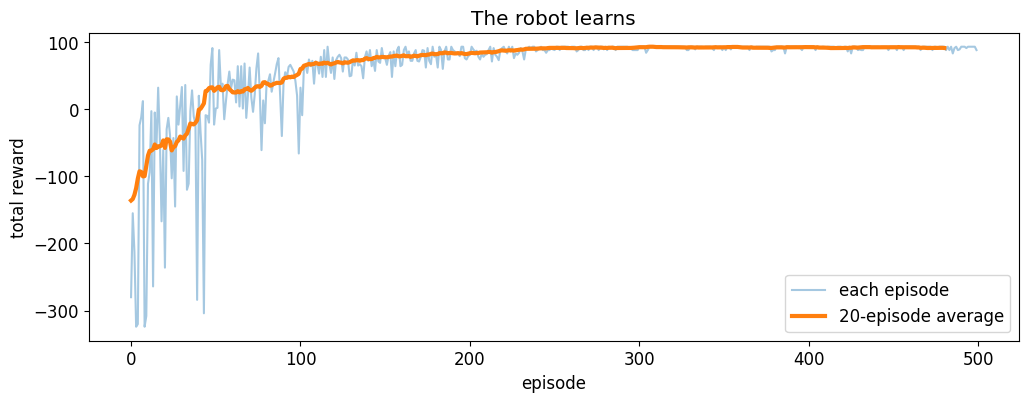

In [5]:
Q = np.zeros((N * N, 4))
alpha, gamma = 0.1, 0.95
rng = np.random.default_rng(0)
episode_rewards = []

for episode in range(500):
    epsilon = max(0.05, 1 - episode / 300)       # explore a lot at first, less later
    state, total = 0, 0
    for t in range(100):
        if rng.random() < epsilon:
            action = rng.integers(4)                  # explore
        else:
            action = int(np.argmax(Q[state]))         # exploit
        new_state, reward, done = step(state, action)
        best_next = 0 if done else np.max(Q[new_state])
        Q[state, action] += alpha * (reward + gamma * best_next - Q[state, action])
        state, total = new_state, total + reward
        if done: break
    episode_rewards.append(total)

print("Average reward, first 50 episodes:", np.mean(episode_rewards[:50]))
print("Average reward, last 50 episodes: ", np.mean(episode_rewards[-50:]))
plt.figure(figsize=(12, 4))
plt.plot(episode_rewards, alpha=0.4, label="each episode")
plt.plot(np.convolve(episode_rewards, np.ones(20) / 20, mode="valid"), linewidth=3, label="20-episode average")
plt.xlabel("episode"); plt.ylabel("total reward"); plt.legend(); plt.title("The robot learns"); plt.show()

---
## Part 2 · What did the robot learn?

In [6]:
state, path = 0, [0]
for t in range(20):
    state, reward, done = step(state, int(np.argmax(Q[state])))
    path.append(state)
    if done: break
print(f"Trained robot reaches the goal in {len(path) - 1} moves:\n")
show(path=path)

Trained robot reaches the goal in 8 moves:

 S  ·  ·  ·  . 
 .  █  █  ·  · 
 .  .  .  █  · 
 █  █  .  █  · 
 .  .  .  .  G 


In [7]:
# The policy: the best arrow in every square
print("Best move in each square:\n")
for r in range(N):
    row = ""
    for c in range(N):
        s = r * N + c
        row += " █ " if grid[r, c] == 1 else (" G " if grid[r, c] == 2 else f" {arrows[int(np.argmax(Q[s]))]} ")
    print(row)

Best move in each square:

 →  →  →  ↓  ↓ 
 ↑  █  █  →  ↓ 
 →  →  ↓  █  ↓ 
 █  █  ↓  █  ↓ 
 →  →  →  →  G 


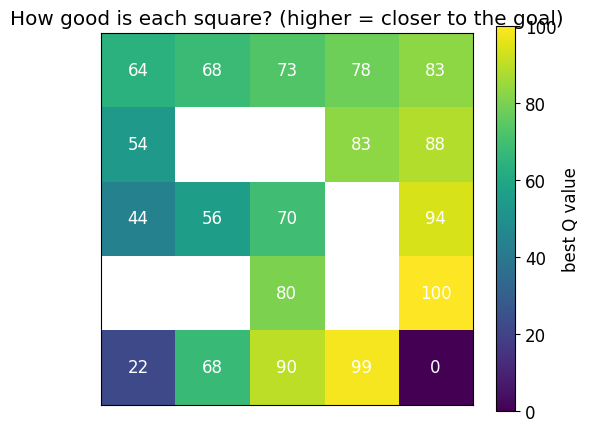

In [8]:
# The value of each square = the best Q score there
values = Q.max(axis=1).reshape(N, N)
values[grid == 1] = np.nan
plt.figure(figsize=(6, 5))
plt.imshow(values, cmap="viridis"); plt.colorbar(label="best Q value")
for r in range(N):
    for c in range(N):
        if grid[r, c] != 1:
            plt.text(c, r, f"{values[r, c]:.0f}", ha="center", va="center", color="white", fontsize=12)
plt.title("How good is each square? (higher = closer to the goal)"); plt.xticks([]); plt.yticks([]); plt.show()

🧠 Nobody told the robot the route. It discovered the **shortest path** (8 moves) purely from rewards. The values grow as you get closer to G — the reward "flows backwards" through the Q-table.

✍️ **Exercise 1:** make bumping much worse (−50 instead of −5) or make each move free (0 instead of −1). Re-run Parts 1–2. Does the route change? What happens to learning speed?

---
## Part 3 · A self-driving taxi (Gymnasium)
**Gymnasium** is the standard library of RL practice worlds. In **Taxi**, a taxi on a 5×5 map must pick up a passenger at one of four stops (R, G, Y, B) and drop them at their destination.

- 500 states (taxi position × passenger location × destination), 6 actions (4 moves, pick up, drop off)
- Rewards: **+20** for a correct drop-off, **−1** per step, **−10** for an illegal pick-up/drop-off

In [9]:
import gymnasium as gym
env_id = "Taxi-v4" if "Taxi-v4" in gym.registry else "Taxi-v3"   # the name depends on the library version
env = gym.make(env_id, render_mode="ansi")
state, _ = env.reset(seed=1)
print(env.render())
print("States:", env.observation_space.n, "  Actions:", env.action_space.n)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


States: 500   Actions: 6


In [10]:
def evaluate(Q=None, episodes=100):
    """Run 100 test trips. Q=None means a random driver."""
    rewards, successes, steps_list = [], 0, []
    for i in range(episodes):
        s, _ = env.reset(seed=1000 + i)
        total = 0
        for t in range(200):
            a = env.action_space.sample() if Q is None else int(np.argmax(Q[s]))
            s, r, terminated, truncated, _ = env.step(a)
            total += r
            if terminated:
                successes += 1; steps_list.append(t + 1); break
            if truncated: break
        rewards.append(total)
    return np.mean(rewards), successes, (np.mean(steps_list) if steps_list else None)

env.action_space.seed(0)
avg, ok, _ = evaluate(None)
print(f"Random driver: average reward {avg:.0f}, delivered {ok} of 100 passengers")

Random driver: average reward -765, delivered 6 of 100 passengers


Trained 5,000 trips in 7.3 seconds


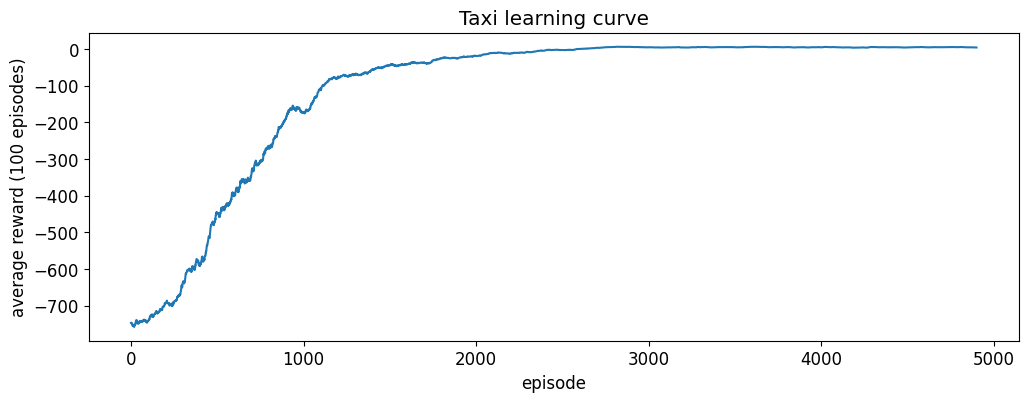

Trained driver: average reward 7.6, delivered 100 of 100 passengers, 13.4 steps per trip


In [11]:
Q = np.zeros((env.observation_space.n, env.action_space.n))
rng = np.random.default_rng(0)
history = []
start = time.time()
for episode in range(5000):
    s, _ = env.reset(seed=episode)
    epsilon = max(0.05, 1 - episode / 3000)
    total = 0
    for t in range(200):
        a = env.action_space.sample() if rng.random() < epsilon else int(np.argmax(Q[s]))
        s2, r, terminated, truncated, _ = env.step(a)
        best_next = 0 if terminated else np.max(Q[s2])
        Q[s, a] += 0.1 * (r + 0.99 * best_next - Q[s, a])
        s, total = s2, total + r
        if terminated or truncated: break
    history.append(total)
print(f"Trained 5,000 trips in {time.time() - start:.1f} seconds")

plt.figure(figsize=(12, 4))
plt.plot(np.convolve(history, np.ones(100) / 100, mode="valid"))
plt.xlabel("episode"); plt.ylabel("average reward (100 episodes)"); plt.title("Taxi learning curve"); plt.show()

avg, ok, steps = evaluate(Q)
print(f"Trained driver: average reward {avg:.1f}, delivered {ok} of 100 passengers, {steps:.1f} steps per trip")

In [12]:
# Watch one trip
s, _ = env.reset(seed=7)
for t in range(30):
    clear_output(wait=True)
    print(env.render()); print("step", t)
    s, r, terminated, truncated, _ = env.step(int(np.argmax(Q[s])))
    time.sleep(0.4)
    if terminated:
        clear_output(wait=True); print(env.render()); print(f"Passenger delivered in {t + 1} steps! 🎉"); break

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)

Passenger delivered in 11 steps! 🎉


🧠 A Q-table works for 500 states. A real robot's camera sees millions of possible images — too many for a table. **Deep RL** replaces the table with a **neural network** (Day 4) that *predicts* the Q values: that's how DeepMind's agents learned Atari games and Go.

✍️ **Exercise 2:** train the taxi for only **500** episodes (and `epsilon = max(0.05, 1 - episode / 300)`). How many passengers does it deliver now?

---
## ✅ Summary
- RL = learn from rewards by trial and error: agent, environment, state, action, reward.
- Q-learning keeps a table of "how good is action *a* in state *s*" and updates it after every move.
- Explore vs exploit: ε-greedy tries random moves early, uses what it learned later.
- Random taxi: a handful of deliveries; trained taxi: all of them, in a few seconds of training.

---
## Solutions

In [ ]:
# Exercise 1: in our run BOTH changes still give the 8-move shortest route.
# Why does it still hurry when moves are free? The discount gamma = 0.95: a +100 reached
# 8 moves from now is worth more than +100 reached 20 moves from now. Try gamma = 1.0 with free moves!
def train_grid(bump=-5, move=-1, episodes=500):
    def step2(state, action):
        r, c = divmod(state, N); dr, dc = moves[action]; nr, nc = r + dr, c + dc
        if not (0 <= nr < N and 0 <= nc < N) or grid[nr, nc] == 1: return state, bump, False
        ns = nr * N + nc
        return (ns, 100, True) if grid[nr, nc] == 2 else (ns, move, False)
    Q2 = np.zeros((N * N, 4)); rng = np.random.default_rng(0)
    for ep in range(episodes):
        eps = max(0.05, 1 - ep / 300); s = 0
        for t in range(100):
            a = rng.integers(4) if rng.random() < eps else int(np.argmax(Q2[s]))
            ns, r, d = step2(s, a); Q2[s, a] += 0.1 * (r + 0.95 * (0 if d else Q2[ns].max()) - Q2[s, a]); s = ns
            if d: break
    s, n = 0, 0
    for n in range(1, 30):
        s, r, d = step2(s, int(np.argmax(Q2[s])))
        if d: break
    return n
print("bump -50: route length", train_grid(bump=-50))
print("free moves: route length", train_grid(move=0))

In [ ]:
# Exercise 2
Q = np.zeros((env.observation_space.n, env.action_space.n)); rng = np.random.default_rng(0)
for episode in range(500):
    s, _ = env.reset(seed=episode); epsilon = max(0.05, 1 - episode / 300)
    for t in range(200):
        a = env.action_space.sample() if rng.random() < epsilon else int(np.argmax(Q[s]))
        s2, r, terminated, truncated, _ = env.step(a)
        Q[s, a] += 0.1 * (r + 0.99 * (0 if terminated else np.max(Q[s2])) - Q[s, a]); s = s2
        if terminated or truncated: break
avg, ok, steps = evaluate(Q)
print(f"500 episodes: average reward {avg:.1f}, delivered {ok} of 100")